In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats


# Metoda najmniejszych kwadratów

In [ ]:
# Dane wejściowe: godziny nauki (x) i wyniki testu (y)
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

# Tworzenie macierzy projektującej X (dodajemy kolumnę jedynek)
X = np.vstack((x, np.ones(len(x)))).T

# Obliczanie współczynników metodą najmniejszych kwadratów
# beta = (X^T X)^(-1) X^T y
beta = np.linalg.inv(X.T @ X) @ X.T @ y

# Wyodrębnienie parametrów a (nachylenie) i b (wyraz wolny)
a, b = beta

print(f"Nachylenie (a): {a}")
print(f"Wyraz wolny (b): {b}")

# Rysowanie wykresu danych i dopasowanej linii regresji
plt.scatter(x, y, color='blue', label='Dane')
plt.plot(x, a * x + b, color='red', label='Linia regresji')
plt.xlabel('Godziny nauki')
plt.ylabel('Wynik z testu')
plt.legend()
plt.title('Metoda najmniejszych kwadratów - Regresja liniowa')
plt.show()

In [ ]:
# Obliczanie reszt (błędów) modelu
residuals = y - (a * x + b)

# Obliczanie wariancji reszt
residual_variance = np.var(residuals, ddof=2)

# Obliczanie macierzy kowariancji parametrów
XTX_inv = np.linalg.inv(X.T @ X)
param_covariance_matrix = residual_variance * XTX_inv

# Błędy standardowe parametrów a i b
param_errors = np.sqrt(np.diag(param_covariance_matrix))

error_a, error_b = param_errors

error_a, error_b

In [ ]:
# Obliczanie współczynnika korelacji Pearsona z macierzy projektującej X i wektora y
# Współczynnik korelacji Pearsona: r = cov(X, y) / (std(X) * std(y))

# Obliczanie średnich
mean_x = np.mean(x)
mean_y = np.mean(y)

# Obliczanie kowariancji
cov_xy = np.sum((x - mean_x) * (y - mean_y)) / (len(x) - 1)

# Obliczanie odchyleń standardowych
std_x = np.std(x, ddof=1)
std_y = np.std(y, ddof=1)

# Obliczanie współczynnika korelacji Pearsona
pearson_coefficient = cov_xy / (std_x * std_y)

pearson_coefficient

# Zadanie 1

Wykorzystując `np.random.normal`, wygeneruj dane testowe (1000 punktów na płaszczyźnie w zależnosci liniowej między x i y) , do których zastosuj metodę najmniejszych kwadratów (możesz użyć **stats.linregres, scipy.optimize.curve_fit, numpy.polyfit**).
- Znajdź parametry prostej $y = a \cdot x + b$ .


Nachylenie (a): 1.9962756708313485
Wyraz wolny (b): 0.9281082308628613


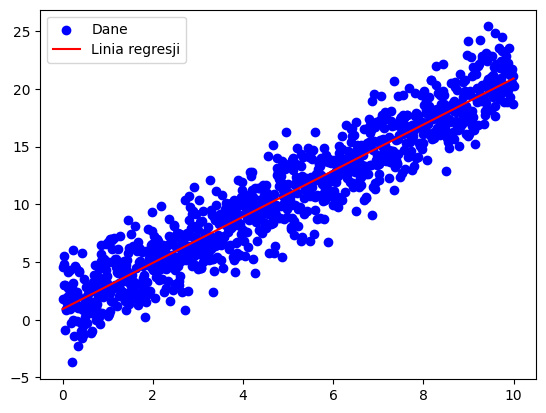

In [ ]:
np.random.seed(0)
x = np.linspace(0, 10, 1000)
y = 2 * x + 1 + np.random.normal(0, 2, 1000)

a, b = np.polyfit(x, y, 1)

print(f"Nachylenie (a): {a}")
print(f"Wyraz wolny (b): {b}")

plt.scatter(x, y, color='blue', label='Dane')
plt.plot(x, a * x + b, color='red', label='Linia regresji')
plt.legend()
plt.show()


# Zadanie 2

Wczytaj dane z pliku **LungDisease.csv** do DataFrame za pomocą biblioteki `pandas`. Dane te zawierają informacje o liczbie lat, przez które pracownik był narażony na pył bawełniany (**Exposure**), oraz o miarze pojemności płuc (**PEFR** - szczytowy przepływ wydechowy).

- Następnie, używając biblioteki matplotlib lub seaborn, stwórz wykres punktowy, na którym na osi x znajdzie się zmienna **Exposure**, a na osi y zmienna **PEFR**.

- Po stworzeniu wykresu, oblicz współczynnik korelacji Pearsona między **Exposure** a **PEFR**, aby ilościowo określić siłę i kierunek zależności między tymi zmiennymi.

- Na koniec, dopasuj prostą regresji liniowej do danych, aby zobaczyć, jak **PEFR** zmienia się w zależności od **Exposure**. Wyświetl wykres z dopasowaną prostą regresji

- Zastanów się, czy na wykresie punktowym widać wyraźny trend lub wzorzec. Czy PEFR rośnie czy maleje wraz z Exposure? Czy są jakieś odstające punkty lub nietypowe dane?

In [2]:
from google.colab import files
uploaded = files.upload()

Saving LungDisease.csv to LungDisease.csv


Korelacja Exposure <-> PEFR: -0.277


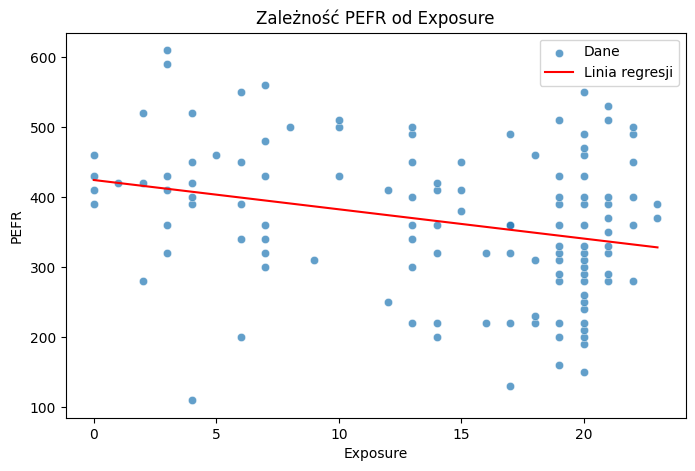

In [12]:
df = pd.read_csv("LungDisease.csv")

plt.figure(figsize=(8,5))
sns.scatterplot(x="Exposure", y="PEFR", data=df, label="Dane", alpha=0.7)

corr_value = df["Exposure"].corr(df["PEFR"])
print(f"Korelacja Exposure <-> PEFR: {corr_value:.3f}")

a, b = np.polyfit(df["Exposure"], df["PEFR"], 1)
x_l = np.linspace(df["Exposure"].min(), df["Exposure"].max(), 100)
y_l = a * x_l + b

plt.plot(x_l, y_l, color="red", label="Linia regresji")
plt.xlabel("Exposure")
plt.ylabel("PEFR")
plt.title("Zależność PEFR od Exposure")
plt.legend()
plt.show()

Współczynnik Pearsona jest jak widać ujemny (**-0.277**), i co widać po linii regresji wraz ze wzrostem **Exposure** maleje **PEFR**.
Trend jest raczej lekko malejący. Korelacja istnieje, lecz stosunkowo słaba, a rozrzut punktów jest duży, może to sugerować że inne czynniki silniej wpływają na PERF.

# Zadanie 3

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.

3. **Dopasuj funkcje liniowe:**
   - Dla każdej pary `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4` dopasuj funkcję liniową w postaci $y = a \cdot x + b$.
   - Oblicz współczynniki `a` i `b` wraz z błędami dla każdej pary.

4. **Oblicz współczynnik korelacji:**
   - Oblicz współczynnik korelacji Pearsona dla każdej pary `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.



In [13]:
from google.colab import files
uploaded = files.upload()

Saving anscombe.csv to anscombe.csv


In [20]:
df = pd.read_csv("anscombe.csv")

df.columns = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
df = df.iloc[1:].reset_index(drop=True)

print(df.head())

     x1    y1    x2    y2    x3     y3   x4    y4
0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
2  13.0  7.58  13.0  8.74  13.0  12.74  8.0  7.71
3   9.0  8.81   9.0  8.77   9.0   7.11  8.0  8.84
4  11.0  8.33  11.0  9.26  11.0   7.81  8.0  8.47


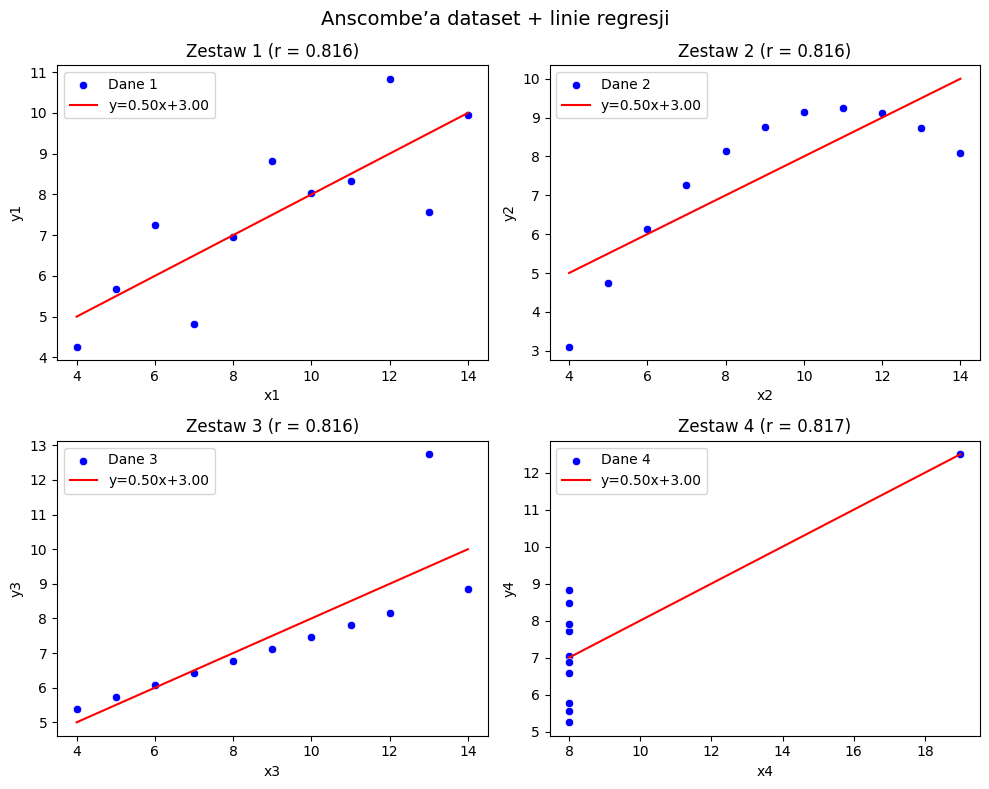

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(1, 5):
    if i == 1:
        ax = axes[0, 0]
    elif i == 2:
        ax = axes[0, 1]
    elif i == 3:
        ax = axes[1, 0]
    else:
        ax = axes[1, 1]

    x = df[f'x{i}'].astype(float)
    y = df[f'y{i}'].astype(float)

    sns.scatterplot(x=x, y=y, ax=ax, color='blue', label=f'Dane {i}')

    a, b = np.polyfit(x, y, 1)
    x_l = np.linspace(x.min(), x.max(), 100)
    y_l = a * x_l + b

    ax.plot(x_l, y_l, color='red', label=f'y={a:.2f}x+{b:.2f}')

    corr = x.corr(y)

    ax.set_title(f'Zestaw {i} (r = {corr:.3f})')
    ax.legend()

plt.suptitle("Anscombe’a dataset + linie regresji", fontsize=14)
plt.tight_layout()
plt.show()